In [ ]:
!pip install kaggle

from google.colab import files
files.upload()

!kaggle datasets download -d polavr/twoclass-weather-classification

!unzip -q twoclass-weather-classification.zip -d weather_data

!ls weather_data

Saving archive.zip to archive (1).zip
Dataset URL: https://www.kaggle.com/datasets/polavr/twoclass-weather-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 107M/107M [00:01<00:00, 87.7MB/s] 

test  train


Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 253 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.7790 - loss: 0.4525 - val_accuracy: 0.8350 - val_loss: 0.3830
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.8334 - loss: 0.3662 - val_accuracy: 0.8170 - val_loss: 0.3962
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.8409 - loss: 0.3550 - val_accuracy: 0.8625 - val_loss: 0.3288
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.8410 - loss: 0.3511 - val_accuracy: 0.8690 - val_loss: 0.3037
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 486s 1s/step - accuracy: 0.8546 - loss: 0.3236 - val_accuracy: 0.8895 - val_loss: 0.2782
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.8574 - loss: 0.3180 - val_accuracy: 0.8820 - val_loss: 0.2916
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 485s 1s/step - accuracy: 0.8622 - loss: 0.3114 - val_accuracy: 0.8945 - val_loss: 0.2549
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 483s 1s/step - accuracy: 0.8645 - loss: 0.3052 - val_accu

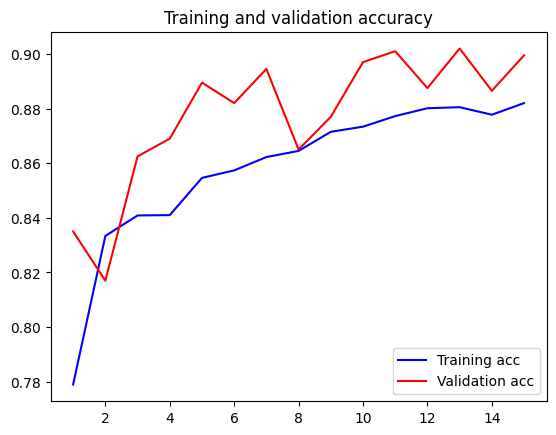

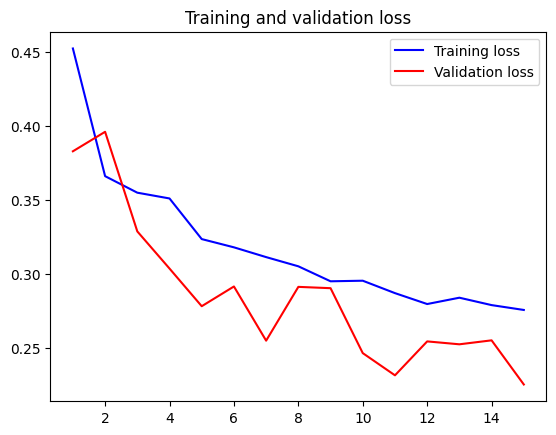

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# ---------- المسارات ----------
train_dir = '/content/weather_data/train'
test_dir = '/content/weather_data/test'

# ---------- معاملات ----------
batch_size = 20
image_size = (150, 150)  # نفس حجم الكود المرجعي

# ---------- تجهيز البيانات ----------
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2)  # نأخذ 20% كـ Validation

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training')

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation')

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=1,
    class_mode='binary',
    shuffle=False)

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size)

test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples)
print(f'Test accuracy: {test_acc:.3f}')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
# 1. تحميل مكتبة Kaggle
!pip install kaggle -q

# 2. رفع ملف التوثيق (ستحتاجين رفع kaggle.json مرة أخرى)
from google.colab import files
files.upload()  # اختاري ملف kaggle.json من جهازك

In [ ]:
# 3. تحميل dataset
!kaggle datasets download -d polavr/twoclass-weather-classification

# 4. فك الضغط
!unzip -q twoclass-weather-classification.zip -d weather_data

# 5. التأكد من وجود المجلدات
!ls weather_data

Dataset URL: https://www.kaggle.com/datasets/polavr/twoclass-weather-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 107M/107M [00:01<00:00, 103MB/s] 

test  train


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# ---------- المسارات الصحيحة بناءً على رسالة 'test train' ----------
train_dir = '/content/weather_data/train'
test_dir = '/content/weather_data/test'

# ---------- المعاملات ----------
batch_size = 20
image_size = (150, 150)

# ---------- تعريف مولدات البيانات ----------
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2)  # 20% للتحقق

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training')  # 80% للتدريب

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation')  # 20% للتحقق

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=1,
    class_mode='binary',
    shuffle=False)

# ---------- عرض عدد الصور لكل مولد (للتأكد) ----------
print(f"\nعدد صور التدريب (Training samples): {train_generator.samples}")
print(f"عدد صور التحقق (Validation samples): {validation_generator.samples}")
print(f"عدد صور الاختبار (Test samples): {test_generator.samples}")

# ---------- بناء نموذج VGG16 ----------
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))
vgg_base.trainable = False  # تجميد الطبقات

model_vgg = Sequential([
    vgg_base,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # لمنع الـ Overfitting
    Dense(1, activation='sigmoid')
])

model_vgg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ---------- عرض ملخص النموذج (اختياري) ----------
model_vgg.summary()

# ---------- تدريب النموذج ----------
print("\nبدء تدريب نموذج VGG16...")
history_vgg = model_vgg.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,  # تدريب لمدة 10 دورات
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

# ---------- تقييم النموذج ----------
print("\nتقييم نموذج VGG16 على بيانات الاختبار...")
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_generator, steps=test_generator.samples)
print(f'\n========== النتيجة النهائية ==========')
print(f'دقة نموذج VGG16 على بيانات الاختبار: {test_acc_vgg:.3f} ({test_acc_vgg * 100:.2f}%)')

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 253 images belonging to 2 classes.

عدد صور التدريب (Training samples): 8000
عدد صور التحقق (Validation samples): 2000
عدد صور الاختبار (Test samples): 253


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,910,017 (72.14 MB)

 Trainable params: 4,195,329 (16.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


بدء تدريب نموذج VGG16...
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3004s 8s/step - accuracy: 0.6876 - loss: 0.6174 - val_accuracy: 0.8000 - val_loss: 0.4589
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2997s 7s/step - accuracy: 0.7560 - loss: 0.4999 - val_accuracy: 0.8180 - val_loss: 0.4060
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2979s 7s/step - accuracy: 0.7616 - loss: 0.4789 - val_accuracy: 0.8225 - val_loss: 0.4232
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3018s 7s/step - accuracy: 0.7816 - loss: 0.4571 - val_accuracy: 0.8225 - val_loss: 0.3907
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3023s 7s/step - accuracy: 0.7860 - loss: 0.4441 - val_accuracy: 0.8450 - val_loss: 0.3536
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3019s 7s/step - accuracy: 0.7971 - loss: 0.4351 - val_accuracy: 0.8265 - val_loss: 0.3871
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2967s 7s/step - accuracy: 0.7975 - loss: 0.4261 - val_accuracy: 0.8380 - val_loss: 0.3488
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3059s 8s/step - accuracy